In [1]:
%load_ext autoreload
%autoreload 2

# Decoder-only model

In [5]:
from src.models.decoder_model import DecoderModel

# Parámetros del modelo
input_dim = 4     # features de las acciones
num_heads = 8
head_dim = 16
num_layers = 8

# Crear modelo
model = DecoderModel(
    input_dim=input_dim,
    num_heads=num_heads,
    head_dim=head_dim,
    num_layers=num_layers,
    dropout_rate=0.1
)

In [3]:
from src.training import load_dataset

dataset_easy = load_dataset("datasets/E4_1-1.data")
dataset_medium = load_dataset("datasets/E4_2-8.data")
dataset_hard = load_dataset("datasets/E4_9-64.data")

In [ ]:
from src.training import curriculum_learning

epochs = 100
train_set = [dataset_easy]
train_size = 1000
test_sets = [dataset_easy, dataset_medium, dataset_hard]
test_size = 400
batch_size = 32
learning_rate = 1e-4
patience = 5
seed = 42

stats = curriculum_learning(model, epochs, train_set, train_size, test_sets, test_size, batch_size, learning_rate, patience, seed)

Epoch 1/100 - Train Loss: 1.4782, Train Accuracy: 66.05% - Val Loss: 0.7691, Val Accuracy: 86.00%
    Test Set: datasets/E4_1-1.data - Val Loss: 0.7691, Val Accuracy: 86.00%
    Test Set: datasets/E4_2-8.data - Val Loss: 4.8745, Val Accuracy: 4.50%
    Test Set: datasets/E4_9-64.data - Val Loss: 9.8123, Val Accuracy: 0.20%
    Average - Val Loss: 5.1520, Val Accuracy: 30.23%


KeyboardInterrupt: 

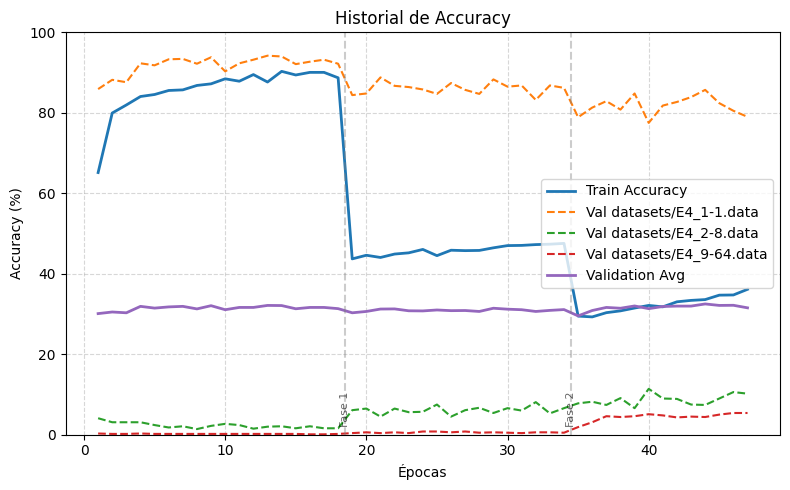

In [116]:
stats.plot()

In [26]:
from src.training import *

save_model(model, "decoder.pth")

In [8]:
import gc
gc.collect()

0